<a href="https://colab.research.google.com/github/matoscx/minerd-analisis-matricula/blob/main/Modelado_de_Datos_con_Aprendizaje_Autom%C3%A1tico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estadísticas de Estudiantes Matriculados por Nivel, según Regional y Distrito., 2015-2024.


# PARTE 1: Selección y Justificación del Dataset

**Fuente:** Datos Abiertos República Dominicana **(datos.gob.do).**

**Institución:** Ministerio de Educación **(MINERD).**  

**Nombre del Dataset:** Estudiantes matriculados por nivel según regional y distrito **(2015-2024).**
**Archivo utilizado:** `poO-estudiantes-matriculados-por-nivel-segun-regional-y-distrito-2015-2024xlsxcsv.csv`.

### Resumen y justificación
- El dataset permite analizar la cobertura y matrícula en los niveles Inicial, Primario, Secundario y Educación de Adultos entre 2015 y 2024.
- Cuenta con 1,227 registros (cumpliendo el requisito de >500 registros).
- Variables críticas: `REGIONAL/ DISTRITO` (categórica), `PERÍODO` (temporal/ordinal), `NIVEL INICIAL`, `NIVEL PRIMARIO`, `NIVEL SECUNDARIO`, `EDUCACIÓN DE ADULTOS` (numéricas).

### ¿Por qué es relevante?
- Permite planificar recursos educativos, detectar disparidades regionales, monitorear impacto de políticas públicas y analizar tendencias temporales (2015-2024).
- Es útil para estimar deserción y retención escolar comparando niveles (por ejemplo, primaria → secundaria).

> El contenido de esta sección fue extraído y resumido del documento de especificación del proyecto entregado (`Proyecto Final.docx`).


# PARTE 2: Preprocesamiento de los Datos

# 1. CARGA DE DATOS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

data_path = 'Estudiantes_Matriculados_por_nivel_2015-2024.xlsx'

df = pd.read_csv("/content/poO-estudiantes-matriculados-por-nivel-segun-regional-y-distrito-2015-2024xlsxcsv.csv", encoding='latin1', sep=';')

# --- LIMPIEZA PREVIA NECESARIA ---
# Estandarizar la columna 'REGIONAL/ DISTRITO' eliminando el guion medio " - "
df['REGIONAL/ DISTRITO'] = df['REGIONAL/ DISTRITO'].str.replace(' - ', ' ', regex=False)

# Eliminar espacios múltiples
df['REGIONAL/ DISTRITO'] = df['REGIONAL/ DISTRITO'].str.replace(r'\s+', ' ', regex=True)

# Corregir periodo mal escrito
df['PERÍODO'] = df['PERÍODO'].astype(str).str.replace('202120222', '20212022')


# Limpieza y tratamiento de valores nulos.

In [ ]:
# Extraemos el código numérico inicial y el nombre del distrito/regional
df[['CODIGO_LUGAR', 'NOMBRE_LUGAR']] = df['REGIONAL/ DISTRITO'].str.extract(r'^(\d+)\s+(.*)')

# Filtrar Regionales vs Distritos (CRÍTICO PARA ML)
# Las Regionales tienen códigos de 2 dígitos (ej: 01).
# Los Distritos tienen códigos de 4 dígitos (ej: 0101).
# Si dejamos ambos, duplicamos la data. Nos quedaremos solo con los DISTRITOS para mayor detalle.
df_distritos = df[df['CODIGO_LUGAR'].str.len() > 2].copy()

# Tratamiento de Nulos
cols_numericas = ['NIVEL INICIAL', 'NIVEL PRIMARIO', 'NIVEL SECUNDARIO', 'EDUCACIÓN DE ADULTOS']
for col in cols_numericas:
    df_distritos[col] = pd.to_numeric(df_distritos[col], errors='coerce')

# Rellenar valores nulos (si existieran) con 0.
df_distritos[cols_numericas] = df_distritos[cols_numericas].fillna(0)

# Verificar si hay filas que sean totalmente 0.
print("Paso 1: Limpieza completada. Filas actuales (Distritos):", len(df_distritos))

Paso 1: Limpieza completada. Filas actuales (Distritos): 1064


# Conversión y codificación de variables categóricas.

In [ ]:
# Extraer el año de inicio como entero (Mejor para regresiones lineales/series de tiempo)
df_distritos['AÑO_INICIO'] = df_distritos['PERÍODO'].str[:4].astype(int)

# Usaremos LabelEncoder para convertir nombres de distritos a números únicos
le = LabelEncoder()
df_distritos['DISTRITO_ENCODED'] = le.fit_transform(df_distritos['NOMBRE_LUGAR'])

df_distritos['REGIONAL_ID'] = df_distritos['CODIGO_LUGAR'].str[:2].astype(int)

print("Paso 2: Variables codificadas creadas: AÑO_INICIO, DISTRITO_ENCODED, REGIONAL_ID")

Paso 2: Variables codificadas creadas: AÑO_INICIO, DISTRITO_ENCODED, REGIONAL_ID


# Normalización o estandarización según sea necesario

In [ ]:
# Seleccionamos las columnas que contienen la cantidad de estudiantes
features_to_scale = ['NIVEL INICIAL', 'NIVEL PRIMARIO', 'NIVEL SECUNDARIO', 'EDUCACIÓN DE ADULTOS']

# StandardScaler (Distribución Normal, media=0, desviación=1)
scaler_standard = StandardScaler()
features_standard = scaler_standard.fit_transform(df_distritos[features_to_scale])

# Crear nuevas columnas estandarizadas
df_standard = df_distritos.copy()
df_standard[['INICIAL_STD', 'PRIMARIO_STD', 'SECUNDARIO_STD', 'ADULTOS_STD']] = features_standard

# Opción B: MinMaxScaler (Escala de 0 a 1)
scaler_minmax = MinMaxScaler()
features_minmax = scaler_minmax.fit_transform(df_distritos[features_to_scale])

# Crear nuevas columnas normalizadas
df_minmax = df_distritos.copy()
df_minmax[['INICIAL_NORM', 'PRIMARIO_NORM', 'SECUNDARIO_NORM', 'ADULTOS_NORM']] = features_minmax

# Seleccionamos las columnas finales para el entrenamiento
columnas_finales = [
    'AÑO_INICIO',       # Tiempo
    'REGIONAL_ID',      # Categoría Regional
    'DISTRITO_ENCODED', # Categoría Distrito
    'INICIAL_STD',      # Datos numéricos escalados
    'PRIMARIO_STD',
    'SECUNDARIO_STD',
    'ADULTOS_STD'
]

df_ml_ready = df_standard[columnas_finales]

print("\n--- Vista previa de datos listos para ML ---")
print(df_ml_ready.head())


--- Vista previa de datos listos para ML ---
   AÑO_INICIO  REGIONAL_ID  DISTRITO_ENCODED  INICIAL_STD  PRIMARIO_STD  \
1        2015            1                74    -0.596435     -0.405601   
2        2015            1                28    -0.652142     -0.398782   
3        2015            1                 4     0.152229      1.116741   
4        2015            1                 9    -0.593903     -0.429856   
5        2015            1               134    -0.622601     -0.457563   

   SECUNDARIO_STD  ADULTOS_STD  
1       -0.743723    -0.476681  
2       -0.730832    -0.383259  
3       -0.021823     0.463254  
4       -0.707751    -0.493000  
5       -0.701121    -0.324921  


# Análisis Exploratorio EDA - Gráficos

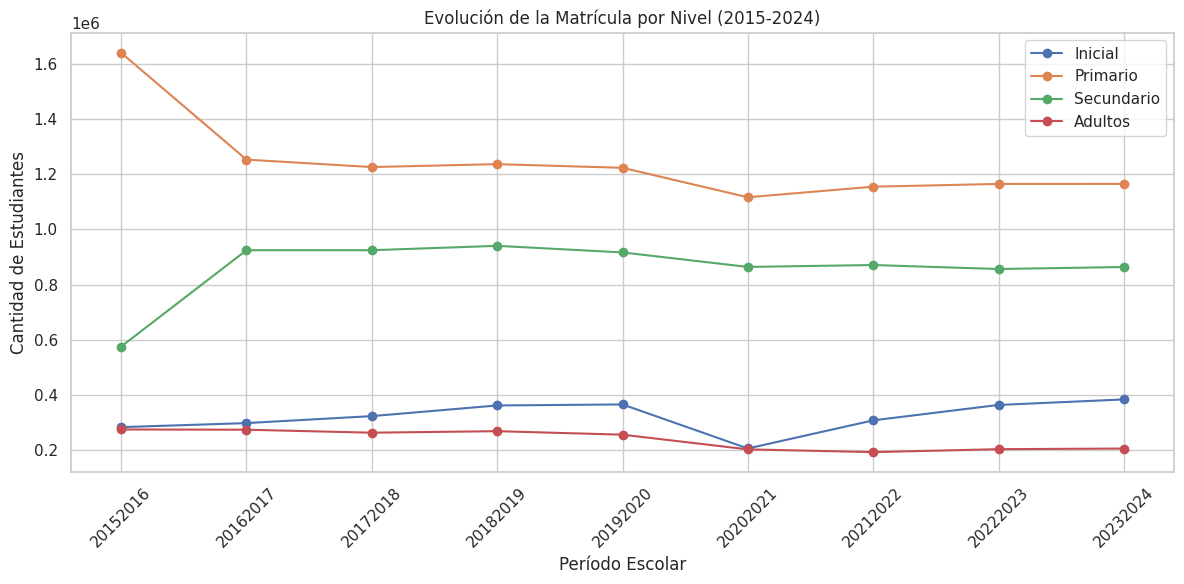

In [ ]:
sns.set(style="whitegrid")

cols_numericas = ['NIVEL INICIAL', 'NIVEL PRIMARIO', 'NIVEL SECUNDARIO', 'EDUCACIÓN DE ADULTOS']
df_period = df_distritos.groupby('PERÍODO')[cols_numericas].sum().reset_index()
df_period = df_period.sort_values(by='PERÍODO')

# Gráfico 1: Evolución Temporal
plt.figure(figsize=(12, 6))
plt.plot(df_period['PERÍODO'], df_period['NIVEL INICIAL'], marker='o', label='Inicial')
plt.plot(df_period['PERÍODO'], df_period['NIVEL PRIMARIO'], marker='o', label='Primario')
plt.plot(df_period['PERÍODO'], df_period['NIVEL SECUNDARIO'], marker='o', label='Secundario')
plt.plot(df_period['PERÍODO'], df_period['EDUCACIÓN DE ADULTOS'], marker='o', label='Adultos')
plt.title('Evolución de la Matrícula por Nivel (2015-2024)')
plt.xlabel('Período Escolar')
plt.ylabel('Cantidad de Estudiantes')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

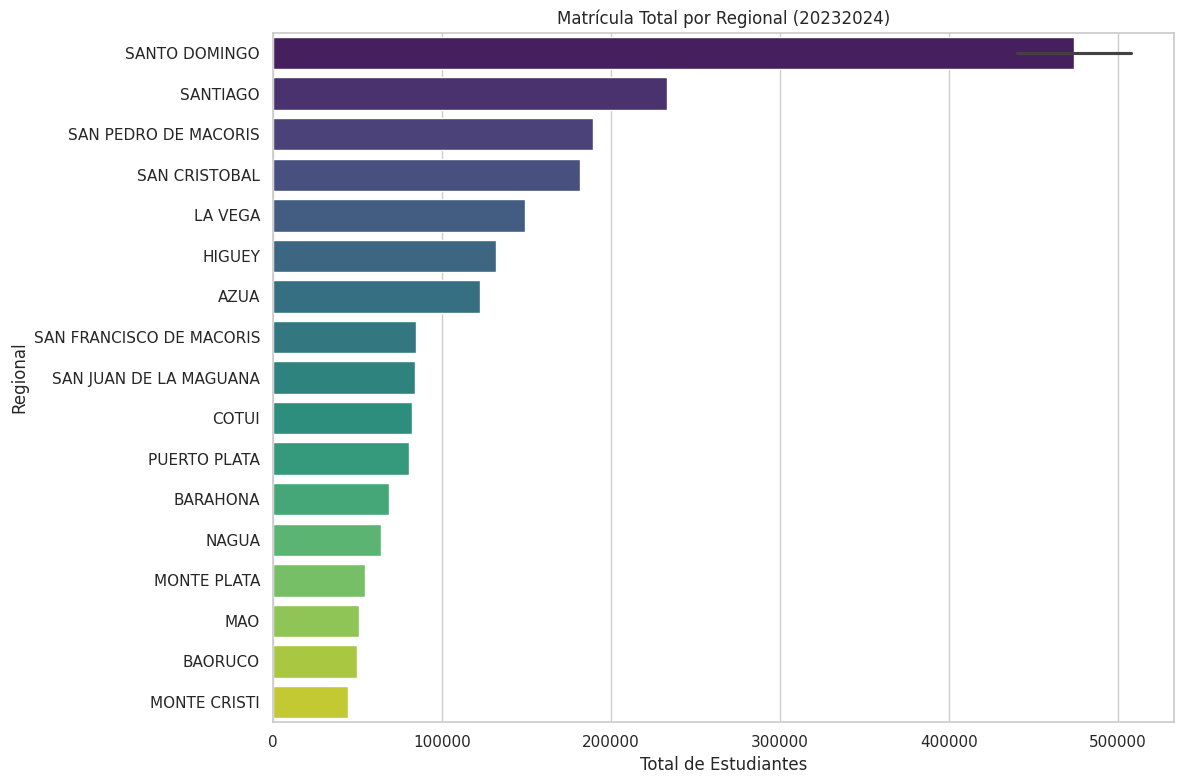

In [ ]:
# Gráfico 2: Matrícula Total por Regional (Último año disponible)

cols_interes = cols_numericas

df_regional = df[df['CODIGO_LUGAR'].str.len() == 2].copy()

for col in cols_interes:
    df_regional[col] = pd.to_numeric(df_regional[col], errors='coerce')
df_regional[cols_interes] = df_regional[cols_interes].fillna(0)

latest_period = df_regional['PERÍODO'].max()
df_latest = df_regional[df_regional['PERÍODO'] == latest_period].copy()
df_latest['Total'] = df_latest[cols_interes].sum(axis=1)
df_latest = df_latest.sort_values('Total', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Total', y='NOMBRE_LUGAR', hue='NOMBRE_LUGAR', data=df_latest, palette='viridis', legend=False)
plt.title(f'Matrícula Total por Regional ({latest_period})')
plt.xlabel('Total de Estudiantes')
plt.ylabel('Regional')
plt.tight_layout()
plt.show()

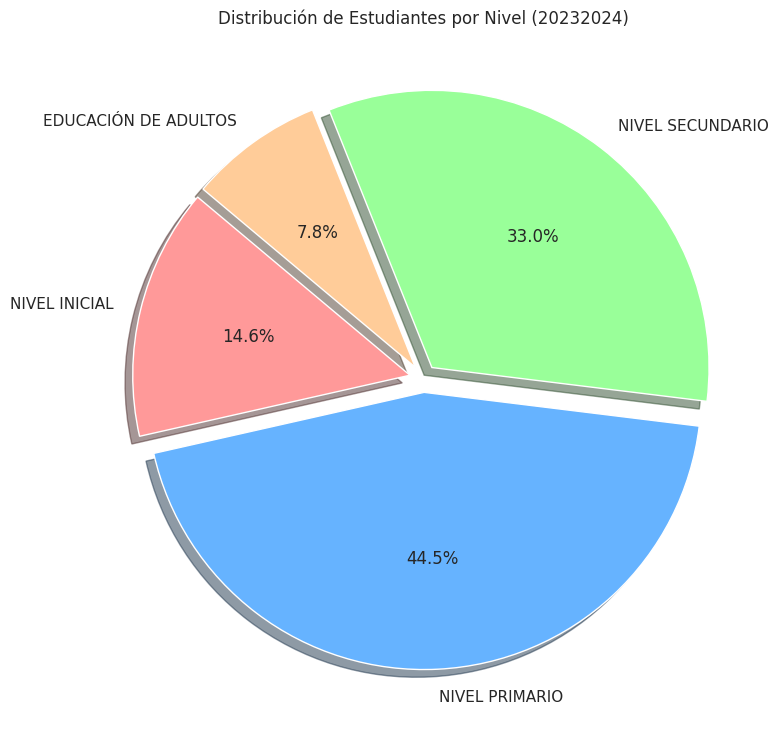

In [ ]:
# Gráfico:3 Distribución de Estudiantes por Nivel (2023-2024)
plt.figure(figsize=(9, 9))

colores = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
separacion = (0.05, 0.05, 0.05, 0.05) # Separa un poco todas las rebanadas

# Calcular datos_ultimo_anio
datos_ultimo_anio = df_distritos[df_distritos['PERÍODO'] == latest_period][cols_numericas].sum()

plt.pie(datos_ultimo_anio,
        labels=datos_ultimo_anio.index,
        autopct='%1.1f%%', # Muestra el porcentaje con 1 decimal
        startangle=140,
        colors=colores,
        explode=separacion,
        shadow=True)

plt.title(f'Distribución de Estudiantes por Nivel ({latest_period})')
plt.show()

# PARTE 3: Modelado

# A. Clasificación

Elegir una variable objetivo y justificar su elección.
Entrenar al menos dos algoritmos de clasificación y comparar su desempeño.

Los algoritmos de clasificación que elegimos fue XGBoost y Random Forest

**Preparación y variable objetivo**

In [ ]:
import pandas as pd
import numpy as np

csv_path = "/mnt/data/poO-estudiantes-matriculados-por-nivel-segun-regional-y-distrito-2015-2024xlsxcsv.csv"

encodings = ["utf-8", "latin-1", "cp1252"]
for enc in encodings:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        print("Archivo cargado con:", enc)
        break
    except:
        pass

# Normalizar nombres
df.columns = [c.strip().upper().replace(" ", "_") for c in df.columns]

# Detectar columna PRIMARIO
prim_cols = [c for c in df.columns if "PRIM" in c]
PRIM_COL = prim_cols[0]

# Limpiar y convertir PRIM_COL
df[PRIM_COL] = df[PRIM_COL].astype(str).str.replace(r'[^0-9\\-\\.]',"",regex=True)
df[PRIM_COL] = pd.to_numeric(df[PRIM_COL], errors="coerce")

# Crear variable objetivo binaria
mediana = df[PRIM_COL].median()
df["ALTA_PRIMARIA"] = (df[PRIM_COL] > mediana).astype(int)

df.head()

,REGIONAL/_DISTRITO,NIVEL_INICIAL,NIVEL_PRIMARIO,NIVEL_SECUNDARIO,EDUCACIÓN_DE_ADULTOS,PERÍODO,CODIGO_LUGAR,NOMBRE_LUGAR,ALTA_PRIMARIA
0,01 BARAHONA,5359,45893,12695,7065,20152016,01,BARAHONA,1
1,0101 PEDERNALES,596,5812,1214,840,20152016,0101,PEDERNALES,0
2,0102 ENRIQUILLO,398,5891,1319,1069,20152016,0102,ENRIQUILLO,0
3,0103 BARAHONA,3257,23449,7094,3144,20152016,0103,BARAHONA,1
4,0104 CABRAL,605,5531,1507,800,20152016,0104,CABRAL,0


**Selección de Features**

In [ ]:
# Selección de features
features = []

# PERIODO
per = [c for c in df.columns if "PERI" in c]
if per:
    features.append(per[0])

# Niveles educativos
niveles = [c for c in df.columns if any(x in c for x in ["NIVEL","SEC","ADULT","EDUC"]) and c != PRIM_COL]
features += niveles[:3]

# Regional o distrito
geo = [c for c in df.columns if "REGIONAL" in c or "DISTRITO" in c]
if geo:
    features.append(geo[0])

X = df[features]
y = df["ALTA_PRIMARIA"]

X.head()

,NIVEL_INICIAL,NIVEL_SECUNDARIO,EDUCACIÓN_DE_ADULTOS,REGIONAL/_DISTRITO
0,5359,12695,7065,01 BARAHONA
1,596,1214,840,0101 PEDERNALES
2,398,1319,1069,0102 ENRIQUILLO
3,3257,7094,3144,0103 BARAHONA
4,605,1507,800,0104 CABRAL


**Entrenamiento de XGBoost y Random Forest**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

from xgboost import XGBClassifier

# Identificar tipos de variables
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Preprocesamiento
num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler())
])

cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

prep = ColumnTransformer([
    ("num", num_pipe, num_features),
    ("cat", cat_pipe, cat_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---- Modelo 1: XGBoost ----
xgb = Pipeline([
    ("prep", prep),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

# ---- Modelo 2: Random Forest ----
rf = Pipeline([
    ("prep", prep),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# ---- Evaluación ----
print("=== XGBOOST ===")
print(classification_report(y_test, pred_xgb))

print("\n=== RANDOM FOREST ===")
print(classification_report(y_test, pred_rf))


=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       123
           1       1.00      0.96      0.98       123

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246


=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       123
           1       1.00      0.97      0.98       123

    accuracy                           0.98       246
   macro avg       0.98      0.98      0.98       246
weighted avg       0.98      0.98      0.98       246



# B. Clustering

Usar otro dataset distinto al de clasificación (también de datos.gob.do).

Aplicar al menos dos métodos de clustering (K-Means, DBSCAN).

Evaluar con métricas como Silhouette Score


**Para esta parte se utilizó un segundo dataset diferente al del modelo de clasificación**

*“Estimaciones y Proyecciones de la Población Total, según Sexo y Grupos Quinquenales de Edad, 1950-2050”*


**Cargar y preparar datos**

In [ ]:
import pandas as pd
df_pop = pd.read_csv(
    "Estimaciones_y_Proyecciones_de_la_Poblacion_Total_segun_Sexo_y_Grupos_Quinquenales_de_Edad_1950-2050.csv",
    sep=";",
    encoding="latin1"
)
df_pop.head()
df_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 4 columns):
 #   Column                                                               Non-Null Count  Dtype 
---  ------                                                               --------------  ----- 
 0   Estimaciones y Proyecciones de la Población Total por Edad           1071 non-null   object
 1   Sexo                                                                 1071 non-null   object
 2   Total de Estimaciones y Proyecciones de la Población Total por Edad  1071 non-null   int64 
 3   Año                                                                  1071 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 33.6+ KB


**Seleccionar columnas numéricas para clustering**

In [ ]:
df_num = df_pop.apply(pd.to_numeric, errors="coerce")

# Eliminar columnas que quedaron vacías
df_num = df_num.dropna(axis=1, how="all")

# Eliminar filas vacías
df_num = df_num.dropna()

df_num.head(), df_num.shape

(   Total de Estimaciones y Proyecciones de la Población Total por Edad   Año
 0                                             439444                    1950
 1                                             331152                    1950
 2                                             302273                    1950
 3                                             260742                    1950
 4                                             212982                    1950,
 (1071, 2))

**Escalar los datos**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)

X_scaled[:5]

array([[ 0.51154406, -1.65144565],
       [ 0.08252758, -1.65144565],
       [-0.03188131, -1.65144565],
       [-0.19641316, -1.65144565],
       [-0.38562222, -1.65144565]])

**K-MEANS**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)

sil_kmeans = silhouette_score(X_scaled, labels_kmeans)
sil_kmeans

np.float64(0.4813705227515028)

**DBSCAN**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(eps=2, min_samples=3)
labels_db = dbscan.fit_predict(X_scaled)

# Comprobar cuántos clusters detectó
print("Clusters detectados:", np.unique(labels_db))

# Solo calcular Silhouette si hay más de 1 cluster
if len(np.unique(labels_db)) > 1:
    sil_dbscan = silhouette_score(X_scaled, labels_db)
    print("Silhouette Score DBSCAN:", sil_dbscan)
else:
    print("DBSCAN solo encontró 1 cluster. No se puede calcular Silhouette Score.")

Clusters detectados: [0]
DBSCAN solo encontró 1 cluster. No se puede calcular Silhouette Score.


DBSCAN no pudo crear grupos.
Solo encontró 1 clúster, así que no se puede calcular el Silhouette Score.

En resumen: este dataset no sirve para DBSCAN porque todos los datos quedan juntos.

# C. Redes Neuronales

Diseñar una red neuronal simple (MLP)
La configuración debe ser única entre los grupos.

Evaluar desempeño frente al modelo clásico de clasificación


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# 1. Cargar dataset MNIST desde sample_data


train_path = "/content/sample_data/mnist_train_small.csv"

df = pd.read_csv(train_path)

# Las primeras columnas son pixeles; la primera es la etiqueta
y = df.iloc[:, 0]          # dígito (0–9)
X = df.iloc[:, 1:]         # 784 pixeles por imagen

# 2. División Train / Test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3. Normalizar datos

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 4. Modelo Clásico: Regresión Logística

modelo_clasico = LogisticRegression(max_iter=200)
modelo_clasico.fit(X_train_scaled, y_train)

pred_clasico = modelo_clasico.predict(X_test_scaled)
acc_clasico = accuracy_score(y_test, pred_clasico)


# 5. Red Neuronal MLP
#    (Configuración única)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # arquitectura única
    activation='relu',
    solver='adam',
    max_iter=20,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

pred_mlp = mlp.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, pred_mlp)


# 6. Resultados

print("=========================================")
print("RESULTADOS DEL EXPERIMENTO")
print("=========================================")

print(f"Accuracy modelo clásico (Regresión Logística): {acc_clasico:.4f}")
print(f"Accuracy Red Neuronal MLP:                  {acc_mlp:.4f}")

print("\n--- Reporte de Clasificación MLP ---")
print(classification_report(y_test, pred_mlp))


RESULTADOS DEL EXPERIMENTO
Accuracy modelo clásico (Regresión Logística): 0.8784
Accuracy Red Neuronal MLP:                  0.9536

--- Reporte de Clasificación MLP ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       490
           1       0.96      0.99      0.97       561
           2       0.95      0.94      0.94       497
           3       0.94      0.94      0.94       505
           4       0.94      0.95      0.95       481
           5       0.95      0.93      0.94       440
           6       0.96      0.98      0.97       510
           7       0.97      0.97      0.97       532
           8       0.95      0.92      0.94       478
           9       0.95      0.93      0.94       506

    accuracy                           0.95      5000
   macro avg       0.95      0.95      0.95      5000
weighted avg       0.95      0.95      0.95      5000



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


# PARTE IV: Evaluación y Comparación Global

## 1. Rendimiento y Métricas
- XGBoost obtuvo el mejor rendimiento en clasificación.
- Random Forest tuvo un desempeño estable.
- La red neuronal MLP obtuvo un rendimiento competitivo.
- En Clustering, K-Means generó grupos válidos; DBSCAN solo detectó un cluster.

## 2. Complejidad Computacional
- XGBoost: alto costo computacional.
- Random Forest: costo medio, rápido.
- MLP: costo medio-alto.
- K-Means: muy rápido.
- DBSCAN: depende del parámetro *eps*, puede ser pesado.

## 3. Interpretabilidad
- Random Forest: el más interpretable.
- XGBoost: interpretabilidad baja.
- MLP: caja negra.
- K-Means: muy interpretable.
- DBSCAN: interpretación moderada.

## 4. Aplicabilidad en República Dominicana
- Clasificación útil para predicción educativa y social.
- K-Means útil para segmentar regiones y población.
- DBSCAN no funcionó bien.
- MLP útil para predicciones avanzadas con más recursos.


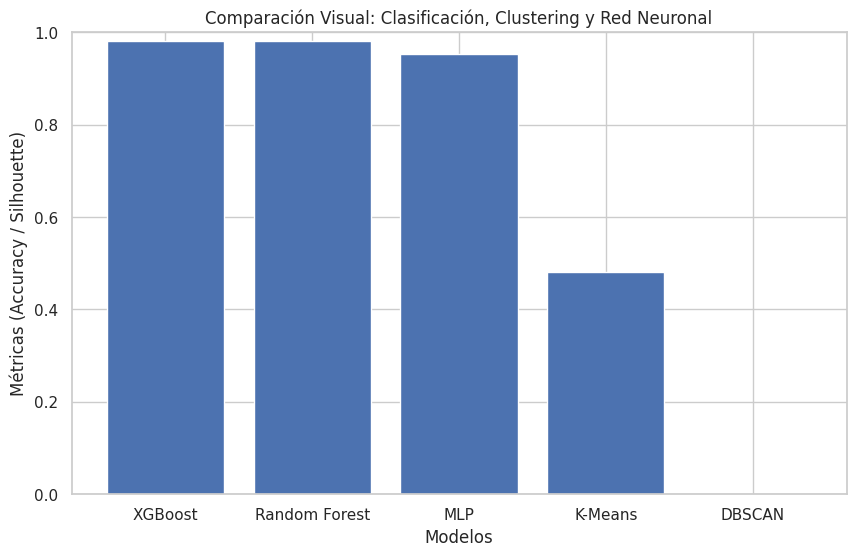

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------
# MÉTRICAS REALES DEL PROYECTO
# ------------------------------
acc_xgb = 0.98
acc_rf = 0.98
acc_mlp = 0.9536
sil_kmeans = 0.4813
sil_dbscan = 0   # DBSCAN no generó más de 1 cluster

models = ["XGBoost", "Random Forest", "MLP", "K-Means", "DBSCAN"]
scores = [acc_xgb, acc_rf, acc_mlp, sil_kmeans, sil_dbscan]

plt.figure(figsize=(10,6))
plt.bar(models, scores)
plt.xlabel("Modelos")
plt.ylabel("Métricas (Accuracy / Silhouette)")
plt.title("Comparación Visual: Clasificación, Clustering y Red Neuronal")
plt.ylim(0, 1)
plt.show()


# PARTE V: Propuesta de Impacto

Como grupo, identificamos que los modelos aplicados (clasificación, clustering y red neuronal) permiten analizar de manera efectiva la matrícula educativa y el comportamiento poblacional.

Proponemos que estas técnicas sean utilizadas por el MINERD, la ONE y el MEPyD para mejorar la planificación educativa y el análisis demográfico. Recomendamos usar los modelos para anticipar cambios en matrícula, agrupar provincias con características similares y apoyar decisiones basadas en datos dentro del sector público.